# Lab 5 - Image Processing
**Student ID:** 2240002024

**Topics:** Spatial Filtering (Smoothing and Sharpening)

This notebook contains the solutions for the three assessment tasks:
1. Convolve an image with a 7x7 box filter
2. Apply 5x5 and 21x21 Gaussian filters
3. Apply a 3x3 Laplacian filter to sharpen an image

## Import Libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage import data

---
## Task #1: 7x7 Box Filter

Convolve an image with a 7x7 box filter, and output the original and smoothed image side by side.

In [2]:
# Load the image (using skimage camera image as a reliable, local source)
image = data.camera()

# Build a 7x7 normalized box kernel so the output stays in the valid range
kernel_size = 7
box_kernel = np.ones((kernel_size, kernel_size), dtype=np.float32) / (kernel_size * kernel_size)

# Convolve the image with the box filter
smoothed = cv2.filter2D(image, ddepth=-1, kernel=box_kernel)

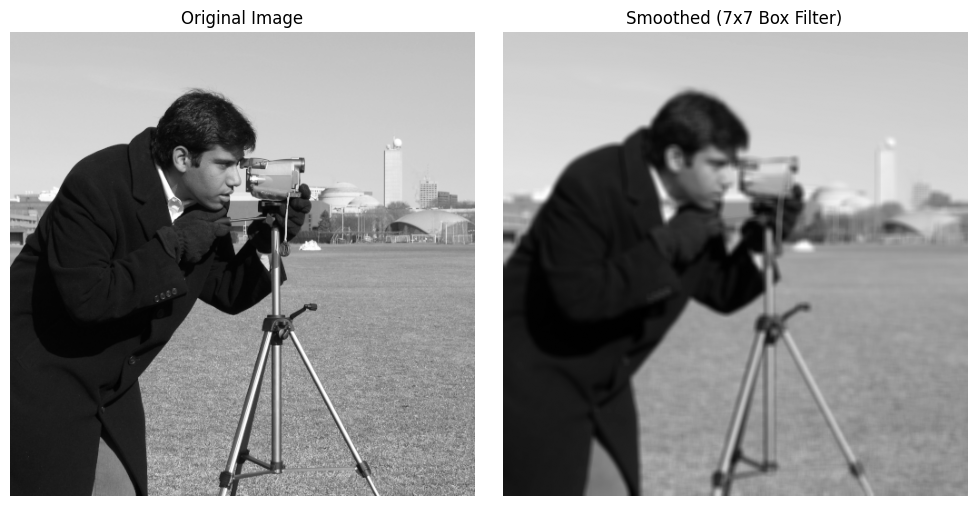

In [3]:
# Display original and smoothed images side by side
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(smoothed, cmap='gray')
ax[1].set_title('Smoothed (7x7 Box Filter)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

---
## Task #2: 5x5 and 21x21 Gaussian Filters

Apply a 5x5 Gaussian filter to the image, then a 21x21 Gaussian filter, and show the three images side by side.

In [4]:
# Load an image of choice
image2 = data.astronaut()

# Apply a 5x5 Gaussian filter (sigma = 0 lets OpenCV derive it from the kernel size)
gaussian_5 = cv2.GaussianBlur(image2, (5, 5), sigmaX=0)

# Apply a 21x21 Gaussian filter
gaussian_21 = cv2.GaussianBlur(image2, (21, 21), sigmaX=0)

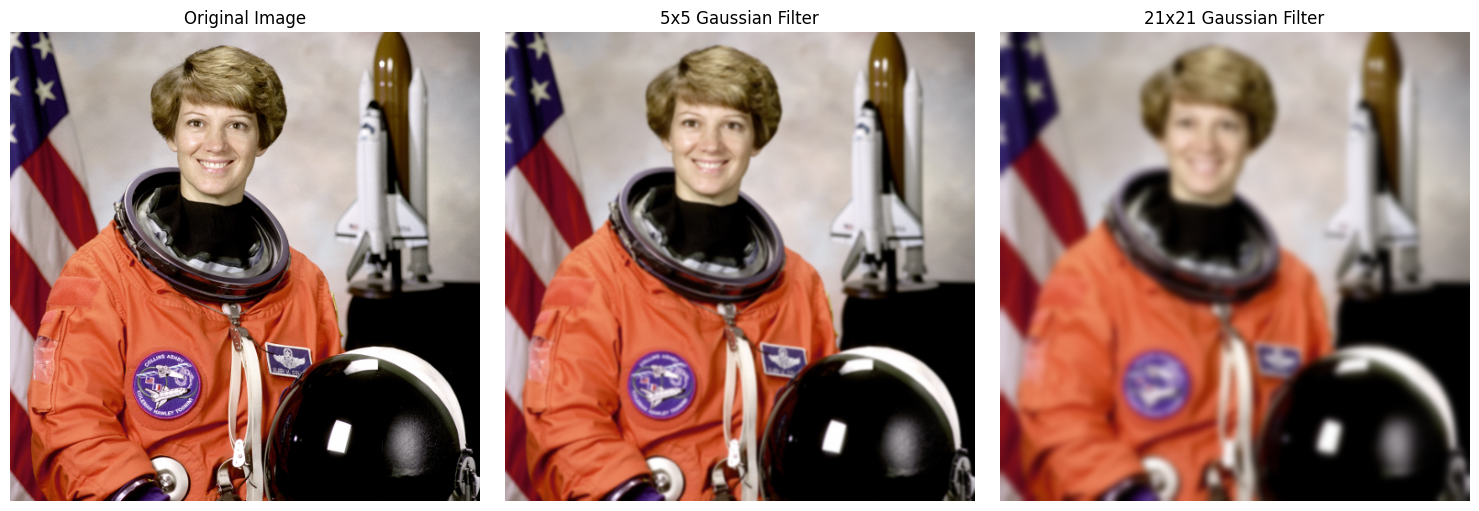

In [5]:
# Display the three images side by side
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image2)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(gaussian_5)
ax[1].set_title('5x5 Gaussian Filter')
ax[1].axis('off')

ax[2].imshow(gaussian_21)
ax[2].set_title('21x21 Gaussian Filter')
ax[2].axis('off')

plt.tight_layout()
plt.show()

---
## Task #3: 3x3 Laplacian Filter for Sharpening

Apply a 3x3 Laplacian filter to sharpen the image. Steps:
1. Read the image
2. Convert image to float32
3. Use the `cv2.Laplacian()` function
4. Sharpen the image using `np.clip(image_float - laplacian, 0, 1)`
5. Plot the original image, the Laplacian result, and the sharpened image

In [6]:
# Step 1: Read the image
image3 = data.coffee()

# Step 2: Convert image to float32 in the [0, 1] range
image_float = image3.astype(np.float32) / 255.0

# Step 3: Apply the 3x3 Laplacian filter
laplacian = cv2.Laplacian(image_float, ddepth=cv2.CV_32F, ksize=3)

# Step 4: Sharpen the image by subtracting the Laplacian and clipping to [0, 1]
sharpened = np.clip(image_float - laplacian, 0, 1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.5444791e-08..0.99999994].


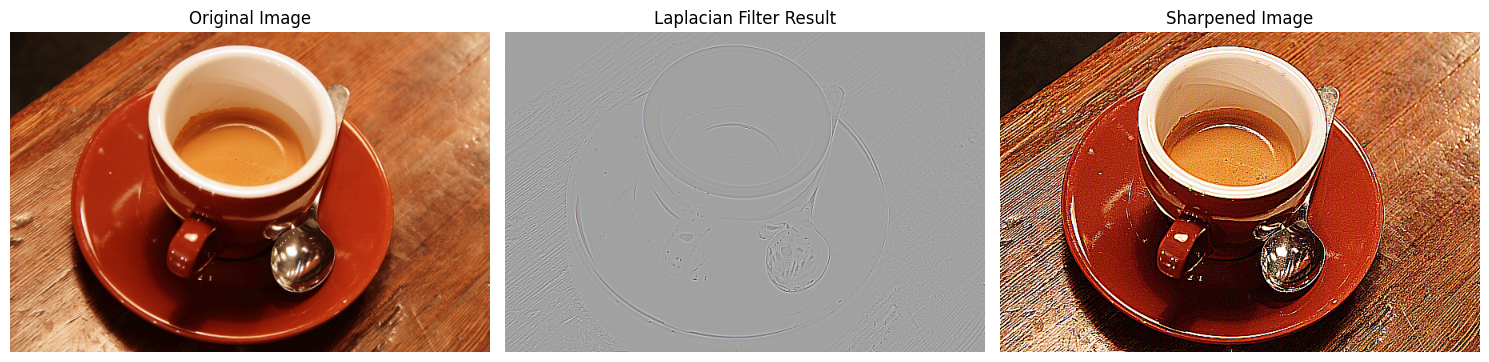

In [7]:
# Step 5: Plot the original, Laplacian, and sharpened images
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(image3)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Normalize the Laplacian for display (it contains negative values)
laplacian_display = cv2.normalize(laplacian, None, 0, 1, cv2.NORM_MINMAX)
ax[1].imshow(laplacian_display)
ax[1].set_title('Laplacian Filter Result')
ax[1].axis('off')

ax[2].imshow(sharpened)
ax[2].set_title('Sharpened Image')
ax[2].axis('off')

plt.tight_layout()
plt.show()

---
## Conclusion

- **Task #1:** The 7x7 box filter averages each pixel with its 48 neighbors, producing a uniform blur that reduces noise but also softens edges.
- **Task #2:** The Gaussian filter weights nearby pixels more heavily than distant ones. A larger kernel (21x21) produces a much stronger blur than a 5x5 kernel because it incorporates a wider neighborhood.
- **Task #3:** The Laplacian highlights regions of rapid intensity change (edges). Subtracting the Laplacian from the original image enhances these edges and produces a sharpened result.